In [63]:
# Tensorflow and tf.keras
import tensorflow as tf
from tensorflow import keras
print("Tensorflow version:",tf.__version__)
print("Keras version:",keras.__version__)

#Helper libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Tensorflow version: 2.20.0
Keras version: 3.13.2


In [64]:
ATT_FILE = "FootballPlayerPreparedCleanAttributes.csv"
LABEL_FILE = "FootballPlayerOneHotEncodedClasses.csv"

attributes = pd.read_csv(ATT_FILE)
labels = pd.read_csv(LABEL_FILE)

In [65]:
from sklearn import model_selection

RANDOM_STATE = 52

# Separamos en train/(validation+test)
train_x, val_and_test_x, train_y, val_and_test_y = model_selection.train_test_split(
    attributes,
    labels,
    random_state=RANDOM_STATE,
    shuffle=True,
    train_size=0.8
)

# Separamos en validation/test 
validation_x, test_x, validation_y, test_y = model_selection.train_test_split(
    val_and_test_x,
    val_and_test_y,
    test_size=0.5, # 0.2 * 0.5 = 0.1 = 10% 
    random_state=RANDOM_STATE
)

In [66]:
print(f"{train_x.shape=} {train_y.shape=}")
print(f"{validation_x.shape=} {validation_y.shape=}")
print(f"{test_x.shape=} {test_y.shape=}")

train_x.shape=(12907, 22) train_y.shape=(12907, 4)
validation_x.shape=(1613, 22) validation_y.shape=(1613, 4)
test_x.shape=(1614, 22) test_y.shape=(1614, 4)


In [67]:
train_x[:4]

,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking
13432,-0.073171,-0.223529,-0.063291,0.041096,-0.275,-0.108434,-0.421687,-0.285714,0.000000,-0.060241,...,0.130435,-0.277778,-0.253012,0.024390,-0.195122,0.047619,-0.048780,-0.15,-0.432432,-0.404762
15228,-0.560976,-0.576471,0.012658,-0.397260,-0.400,-0.638554,-0.542169,-0.476190,-0.729730,-0.469880,...,-0.826087,-0.083333,-0.614458,0.073171,0.146341,-0.571429,-0.439024,-0.15,-0.459459,0.166667
4934,-0.634146,-0.670588,-0.113924,-0.726027,-0.675,-0.590361,-0.518072,-0.571429,-0.675676,-0.590361,...,-0.043478,0.222222,-0.831325,-0.073171,-0.048780,-0.642857,-0.414634,-0.35,-0.567568,-0.095238
10769,-0.317073,-0.294118,-0.113924,0.041096,-0.500,0.156627,-0.445783,-0.452381,0.000000,0.036145,...,-0.188406,0.194444,-0.421687,0.146341,-0.243902,-0.571429,-0.048780,-0.05,-0.567568,-0.071429


In [68]:
train_y[:4]

,"Poor:[np.float64(46.0), np.float64(62.0)]","Interm:[np.float64(63.0), np.float64(66.0)]","Good:[np.float64(67.0), np.float64(71.0)]","Excel:[np.float64(72.0), np.float64(94.0)]"
13432,1.0,0.0,0.0,0.0
15228,1.0,0.0,0.0,0.0
4934,1.0,0.0,0.0,0.0
10769,1.0,0.0,0.0,0.0


In [69]:
INPUTS = train_x.shape[1]
OUTPUTS = train_y.shape[1]

In [70]:
def visualize_history(history, ylim: tuple[float, float] = None):
    results=pd.DataFrame(history)
    results.plot(figsize=(8, 5))
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy - Mean Log Loss")
    if ylim:
        plt.gca().set_ylim(*ylim)
    plt.show()

In [71]:
n_epochs = 30
batch_size = 64

Antes de hacer un modelo profundo, vamos a ver a que rendimiento llegara un modelo sin capas ocultas

In [72]:
from keras import layers 
from keras import models 

first_model = models.Sequential([
    layers.InputLayer(shape=[INPUTS]),
    layers.Dense(OUTPUTS, activation="softmax")
])

Para optimizarlo, usaremos el descenso del gradiente y evaluamos su rendimiento 

In [73]:
from keras import losses 
from keras import optimizers

first_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.SGD(learning_rate=0.1),
    metrics=["categorical_accuracy"]
)

history = first_model.fit(
    train_x,
    train_y,
    batch_size=batch_size,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.4948 - loss: 1.0886 - val_categorical_accuracy: 0.5567 - val_loss: 0.9669
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - categorical_accuracy: 0.5746 - loss: 0.9207 - val_categorical_accuracy: 0.5852 - val_loss: 0.8974
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - categorical_accuracy: 0.6005 - loss: 0.8710 - val_categorical_accuracy: 0.5995 - val_loss: 0.8607
Epoch 4/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - categorical_accuracy: 0.6156 - loss: 0.8417 - val_categorical_accuracy: 0.6138 - val_loss: 0.8371
Epoch 5/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - categorical_accuracy: 0.6275 - loss: 0.8207 - val_categorical_accuracy: 0.6224 - val_loss: 0.8196
Epoch 6/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - categorical_accuracy: 0.6351 - loss: 0.8047 - val_categorical_accuracy: 0.6317 - val_loss: 0.8035
Epoch 7/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - categorical_accuracy: 

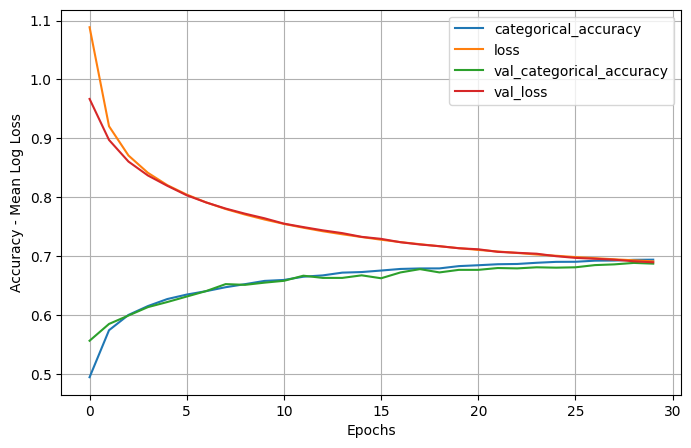

In [74]:
visualize_history(history.history)

Podemos observar que con 30 épocas el modelo no ha convergido del todo. Por lo tanto, podemos continuar su entrenamiento hasta que el modelo converja

In [75]:
new_history = first_model.fit(
    train_x,
    train_y,
    batch_size=batch_size,
    epochs=100,  # 100 mas 
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - categorical_accuracy: 0.6958 - loss: 0.6900 - val_categorical_accuracy: 0.6913 - val_loss: 0.6883
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - categorical_accuracy: 0.6960 - loss: 0.6884 - val_categorical_accuracy: 0.6882 - val_loss: 0.6866
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - categorical_accuracy: 0.6960 - loss: 0.6869 - val_categorical_accuracy: 0.6931 - val_loss: 0.6845
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - categorical_accuracy: 0.6963 - loss: 0.6852 - val_categorical_accuracy: 0.6906 - val_loss: 0.6834
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - categorical_accuracy: 0.6977 - loss: 0.6842 - val_categorical_accuracy: 0.6888 - val_loss: 0.6817
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - categorical_accuracy: 0.6982 - loss: 0.6831 - val_categorical_accuracy: 0.6919 - val_loss: 0.6807
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - categorical_a

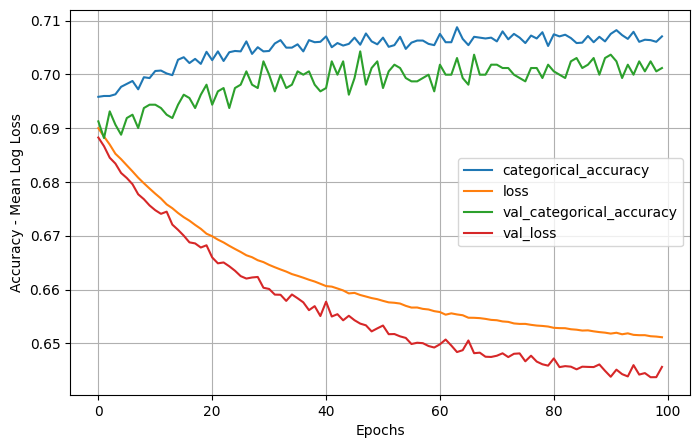

In [76]:
visualize_history(new_history.history)

En base al accuracy podemos decir que el modelo ha convergido y su rendimiento no mejora. 
Para saber si podemos mejorar el rendimiento de nuestro modelo, vamos a añadir capas ocultas. 

Como función de activación vamos a utilizar ReLU, para la inicialización de los pesos usaremos He y para optimizar usaremos Adam. No vamos a utilizar de momento ningún método para la estabilización del entrenamiento o prevención de overfitting. 

In [77]:
second_model = models.Sequential([
  layers.InputLayer(shape=(INPUTS,)),

  layers.Dense(
    64,
    activation="relu",
    kernel_initializer="he_normal"
  ),
  layers.Dense(
    32,
    activation="relu",
    kernel_initializer="he_normal"
  ),
  layers.Dense(
    16,
    activation="relu",
    kernel_initializer="he_normal"
  ),

  layers.Dense(
    OUTPUTS,
    activation="softmax",
    kernel_initializer="he_normal",
  ),
])

In [78]:
second_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999
    ),
    metrics=["categorical_accuracy"]
)

history = second_model.fit(
    train_x,
    train_y,
    batch_size=batch_size,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - categorical_accuracy: 0.6221 - loss: 0.8494 - val_categorical_accuracy: 0.7440 - val_loss: 0.5993
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - categorical_accuracy: 0.7616 - loss: 0.5409 - val_categorical_accuracy: 0.8047 - val_loss: 0.4635
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - categorical_accuracy: 0.8139 - loss: 0.4325 - val_categorical_accuracy: 0.8277 - val_loss: 0.4029
Epoch 4/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - categorical_accuracy: 0.8372 - loss: 0.3803 - val_categorical_accuracy: 0.8239 - val_loss: 0.3692
Epoch 5/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - categorical_accuracy: 0.8475 - loss: 0.3580 - val_categorical_accuracy: 0.8338 - val_loss: 0.3568
Epoch 6/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - categorical_accuracy: 0.8506 - loss: 0.3464 - val_categorical_accuracy: 0.8338 - val_loss: 0.3554
Epoch 7/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - categorical_accuracy: 

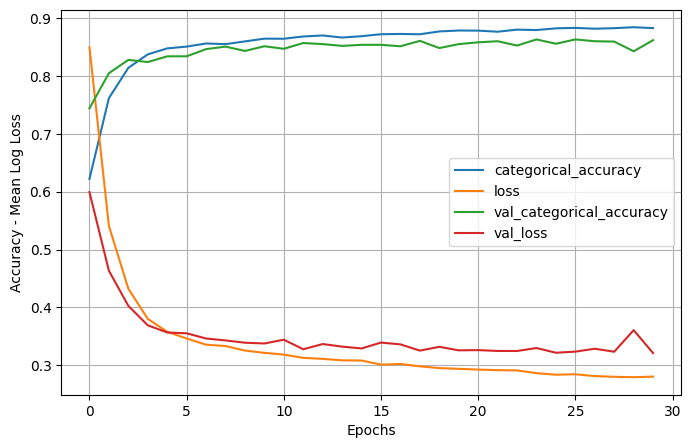

In [79]:
visualize_history(history.history)

En la visualización del accuracy y loss de los conjuntos de entrenamiento y validación podemos ver que las métricas del conjunto de validación no mejoran, mientras que las de entrenamiento si. Por lo tanto, podemos decir que se produce un sobreajuste.  

Podríamos seleccionar un modelo que tenia el mejor resultado sobre el conjunto de validación, pero vamos a intentar combatir el sobreajuste para ver si podemos llegar a un rendimiento mejor. 

Vamos a empezar introduciendo regularización 

In [80]:
from keras import regularizers

regularization = 0.001

third_model = models.Sequential([
  layers.InputLayer(shape=(INPUTS,)),

  layers.Dense(
      64,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dense(
      32,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dense(
      16,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),

  layers.Dense(
      OUTPUTS,
      activation="softmax",
      kernel_initializer="he_normal",
  ),
])

In [81]:
n_epochs = 100

third_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999
    ),
    metrics=["categorical_accuracy"]
)

history = third_model.fit(
    train_x,
    train_y,
    batch_size=batch_size,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - categorical_accuracy: 0.5709 - loss: 1.1454 - val_categorical_accuracy: 0.7378 - val_loss: 0.8160
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - categorical_accuracy: 0.7707 - loss: 0.7172 - val_categorical_accuracy: 0.8134 - val_loss: 0.6251
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - categorical_accuracy: 0.8188 - loss: 0.5922 - val_categorical_accuracy: 0.8351 - val_loss: 0.5454
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - categorical_accuracy: 0.8402 - loss: 0.5312 - val_categorical_accuracy: 0.8500 - val_loss: 0.5138
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - categorical_accuracy: 0.8510 - loss: 0.5031 - val_categorical_accuracy: 0.8481 - val_loss: 0.4951
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - categorical_accuracy: 0.8523 - loss: 0.4835 - val_categorical_accuracy: 0.8506 - val_loss: 0.4715
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - categorical_acc

Mean categorical accuracy:  0.8643934766451518


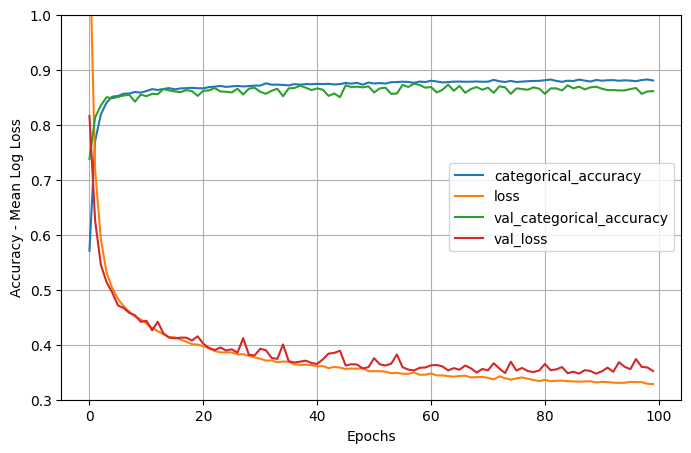

In [82]:
import numpy as np 

print("Mean categorical accuracy: ", np.mean(history.history["val_categorical_accuracy"][-30:]))
visualize_history(history.history, ylim=[0.3, 1])

Vemos que hemos combatido bastante el sobreajuste. Ahora las métricas del conjunto de entrenamiento y validación se parecen mucho. Además, las métricas avanzan de una manera bastante suave y progresiva convergiendo a un nivel de aproximadamente 86.8% de accuracy en el conjunto de validación. 

Vamos a intentar entrenarlo un poco más para ver a que converge con un learning rate más bajo y un batch más grande 

In [83]:
n_epochs = 100

third_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.Adam(
        learning_rate=0.0001,
        beta_1=0.9,
        beta_2=0.999
    ),
    metrics=["categorical_accuracy"]
)

history = third_model.fit(
    train_x,
    train_y,
    batch_size=batch_size * 2,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8879 - loss: 0.3173 - val_categorical_accuracy: 0.8686 - val_loss: 0.3452
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.8902 - loss: 0.3160 - val_categorical_accuracy: 0.8667 - val_loss: 0.3448
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - categorical_accuracy: 0.8910 - loss: 0.3152 - val_categorical_accuracy: 0.8698 - val_loss: 0.3456
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - categorical_accuracy: 0.8897 - loss: 0.3150 - val_categorical_accuracy: 0.8698 - val_loss: 0.3456
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - categorical_accuracy: 0.8888 - loss: 0.3152 - val_categorical_accuracy: 0.8673 - val_loss: 0.3446
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - categorical_accuracy: 0.8908 - loss: 0.3150 - val_categorical_accuracy: 0.8686 - val_loss: 0.3443
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accurac

Mean categorical accuracy:  0.8684439063072205


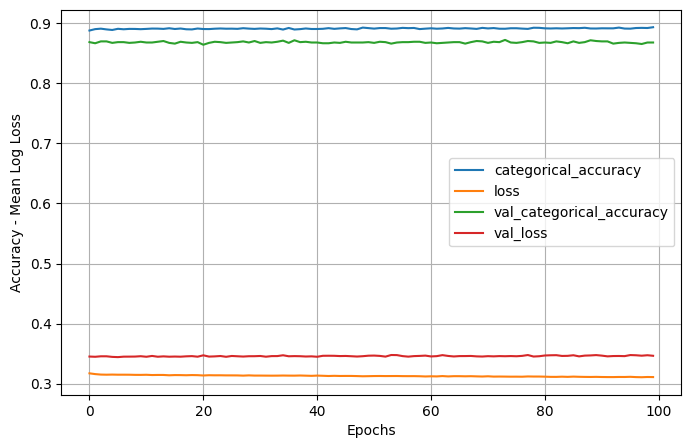

In [84]:
print("Mean categorical accuracy: ", np.mean(history.history["val_categorical_accuracy"][-30:]))
visualize_history(history.history)

Vemos que el loss ha convergido y que el accuracy del conjunto de validación está un poco por debajo del de conjunto de entrenamiento. 

El modelo que hemos desarrollado (third_model), tiene 3 capas ocultas con 64, 32 y 16 neuronas, emplea regularización, sus funciones de activación son ReLU, hemos usado la inicialización de los pesos He y obtenemos un accuracy del conjunto de entrenamiento de 87.1% aproximadamente. 

Todavía no nos vamos a quedar con este modelo porque es posible que al aumentar la cantidad de neuronas o capas podemos llegar a un rendimiento mejor. 

In [85]:
regularization = 0.0001

forth_model = models.Sequential([
  layers.InputLayer(shape=(INPUTS,)),

  layers.Dense(
      512,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),

  layers.Dense(
      256,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),

  layers.Dense(
      128,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),

  layers.Dense(
      64,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),

  layers.Dense(
      OUTPUTS,
      kernel_initializer="he_normal",
      activation="softmax"
  ),
])

In [86]:
n_epochs = 100

forth_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.Adam(
        learning_rate=0.0001,
        beta_1=0.9,
        beta_2=0.999
    ),
    metrics=["categorical_accuracy"]
)

history = forth_model.fit(
    train_x,
    train_y,
    batch_size=batch_size * 2,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.5556 - loss: 1.1642 - val_categorical_accuracy: 0.6596 - val_loss: 0.9476
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.6947 - loss: 0.8822 - val_categorical_accuracy: 0.7347 - val_loss: 0.8106
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.7307 - loss: 0.7890 - val_categorical_accuracy: 0.7495 - val_loss: 0.7537
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.7543 - loss: 0.7380 - val_categorical_accuracy: 0.7688 - val_loss: 0.7079
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.7766 - loss: 0.6995 - val_categorical_accuracy: 0.7799 - val_loss: 0.6878
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.7896 - loss: 0.6665 - val_categorical_accuracy: 0.7874 - val_loss: 0.6569
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.805

Mean categorical accuracy:  0.8522835354010264


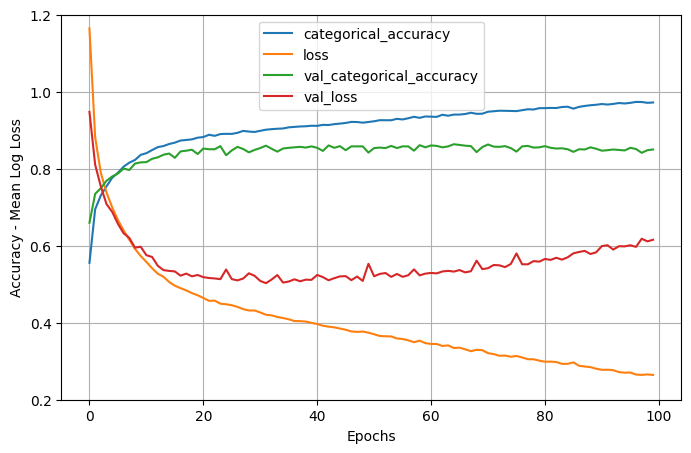

In [87]:
print("Mean categorical accuracy: ", np.mean(history.history["val_categorical_accuracy"][-30:]))
visualize_history(history.history, ylim=[0.2, 1.2])

Se vuelve a producir un sobre entrenamiento. Para compensarlo, vamos a aumentar un poco la regularización y añadir dropout.

In [88]:
regularization = 0.001
dropout_rate = 0.2

forth_model = models.Sequential([
  layers.InputLayer(shape=(INPUTS,)),

  layers.Dense(
      512,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dropout(dropout_rate),

  layers.Dense(
      256,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dropout(dropout_rate),

  layers.Dense(
      128,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dropout(dropout_rate),

  layers.Dense(
      64,
      activation="relu",
      kernel_initializer="he_normal",
      kernel_regularizer=regularizers.L2(regularization)
  ),
  layers.Dropout(dropout_rate / 2),

  layers.Dense(
      OUTPUTS,
      kernel_initializer="he_normal",
      activation="softmax"
  ),
])

In [89]:
n_epochs = 200

forth_model.compile(
    loss=losses.categorical_crossentropy,
    optimizer=optimizers.Adam(
        learning_rate=0.00005,
        beta_1=0.9,
        beta_2=0.999
    ),
    metrics=["categorical_accuracy"]
)

history = forth_model.fit(
    train_x,
    train_y,
    batch_size=batch_size * 2,
    epochs=n_epochs,
    verbose=1,
    validation_data=(validation_x, validation_y)
)

Epoch 1/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.3896 - loss: 3.1852 - val_categorical_accuracy: 0.4954 - val_loss: 2.9456
Epoch 2/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5004 - loss: 2.9473 - val_categorical_accuracy: 0.5406 - val_loss: 2.7967
Epoch 3/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5449 - loss: 2.8295 - val_categorical_accuracy: 0.5945 - val_loss: 2.6972
Epoch 4/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5786 - loss: 2.7405 - val_categorical_accuracy: 0.6305 - val_loss: 2.6147
Epoch 5/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.5954 - loss: 2.6773 - val_categorical_accuracy: 0.6677 - val_loss: 2.5414
Epoch 6/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.6172 - loss: 2.6103 - val_categorical_accuracy: 0.6789 - val_loss: 2.4857
Epoch 7/200
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.634

Mean categorical accuracy:  0.8623062670230865


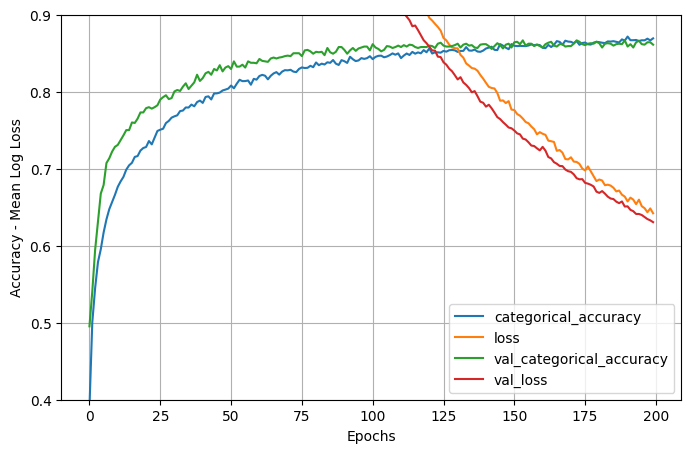

In [90]:
print("Mean categorical accuracy: ", np.mean(history.history["val_categorical_accuracy"][-30:]))
visualize_history(history.history, ylim=[0.4, 0.9])

Vemos que con este modelo que es más grande y profundo, se complica obtener un accuracy mayor. Tuvimos que jugar con la regularización, dropout, learning rate, pero es complicado obtener un rendimiento mucho mayor. 

Por lo tanto, ante tan poca diferencia entre el rendimiento de un modelo más simple y este modelo más complejo, hemos decido quedarnos con el modelo `third_model`. Vamos a evaluar su rendimiento con el conjunto de test. 

In [91]:
model = third_model

model.evaluate(test_x, test_y)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - categorical_accuracy: 0.8724 - loss: 0.3380


[0.33795908093452454, 0.8723667860031128]

Vemos que el rendimiento en el conjunto de test es incluso mayor que con la validación. 

Podemos concluir que el rendimiento que podemos esperar de nuestro modelo final está en torno a 88% de accuracy. 

Vamos a evaluar su rendimiento. 

In [92]:
test_predictions = model.predict(test_x)

predictions = np.argmax(test_predictions,1)
labels = np.argmax(test_y, 1)

predictions[:20] == labels[:20]

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step


array([ True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True])

In [93]:
from collections import Counter

final_test_prediction_results=Counter(
    predictions == labels
)
final_test_prediction_results

Counter({np.True_: 1408, np.False_: 206})

In [94]:
from sklearn.metrics import confusion_matrix

classes = ["Poor", "Intermediate", "Good", "Excellent"]

matrix = pd.DataFrame(
    confusion_matrix(labels, predictions),
    columns=classes
)
matrix.insert(0, "Classes", classes)
matrix["Sum"] = matrix.sum(axis=1, numeric_only=True)
matrix

,Classes,Poor,Intermediate,Good,Excellent,Sum
0,Poor,411,26,0,0,437
1,Intermediate,28,316,46,0,390
2,Good,0,48,350,26,424
3,Excellent,0,0,32,331,363


In [97]:
from sklearn.metrics import classification_report

print(
    classification_report(labels, predictions, target_names=classes)
)

              precision    recall  f1-score   support

        Poor       0.94      0.94      0.94       437
Intermediate       0.81      0.81      0.81       390
        Good       0.82      0.83      0.82       424
   Excellent       0.93      0.91      0.92       363

    accuracy                           0.87      1614
   macro avg       0.87      0.87      0.87      1614
weighted avg       0.87      0.87      0.87      1614

